In [1]:
import numpy as np
import pandas as pd 
from epiweeks import Week
import matplotlib.pyplot as plt 
from scipy.stats import beta, lognorm, norm
from scipy.optimize import minimize
from scipy.interpolate import PchipInterpolator
from mosqlient.scoring import compute_wis 

from mosqlient.prediction_optimize import get_df_pars_ls
import sys
sys.path.append('../')
from aux_func import get_data

In [2]:
challenge = 'dengue_state'

Load data:

In [3]:
df_dengue_state = get_data(challenge)
df_dengue_state.date = pd.to_datetime(df_dengue_state.date)
df_dengue_state.head()

,date,adm_1,casos
0,2010-01-03,11,2456
1,2010-01-03,12,760
2,2010-01-03,13,155
3,2010-01-03,14,25
4,2010-01-03,15,115


Load preds:

In [4]:
df_preds = pd.read_csv(f'../predictions/predictions_all_models_{challenge}.csv.gz', index_col = 'Unnamed: 0')
df_preds.date = pd.to_datetime(df_preds.date)
df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,adm_1,id,validation,wis,model
0,2022-10-09,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
1,2022-10-16,37.019327,43.295517,51.743385,66.653189,83.207109,100.790847,116.992117,126.864602,134.406880,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
2,2022-10-23,55.945220,68.411390,84.200302,108.887826,135.698419,163.344639,189.017119,205.765306,218.575663,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
3,2022-10-30,58.185781,69.697014,83.792687,107.076328,132.601767,158.745145,184.276095,201.204977,212.912726,12,6822,1,95.67,3rd_imdc_isi_isi-dengue
4,2022-11-06,58.634062,68.591352,80.855678,101.969117,125.548661,150.259612,174.517426,190.524410,202.512661,12,6822,1,95.67,3rd_imdc_isi_isi-dengue


Load rank

In [5]:
df_rank = pd.read_csv(f'../predictions/rank_ratio_{challenge}.csv')

model_baseline = '3rd_imdc_procc_bb_model'

df_rank = df_rank.loc[df_rank.model != model_baseline]

df_rank_all = (
    df_rank
    .groupby(["adm_1", "model"], as_index=False)
    .agg(
        geometric_mean_ratio=("wis_ratio", lambda x: np.exp(np.mean(np.log(x)))),
    )
    .sort_values(["adm_1", "geometric_mean_ratio"])
)


df_rank_all['rank'] = df_rank_all.groupby('adm_1')['geometric_mean_ratio'].rank()

df_rank_all.head()

,adm_1,model,geometric_mean_ratio,rank
6,11,3rd_imdc_emap_epidematicos_sarimax_state,0.769598,1.0
19,11,3rd_imdc_pucrio_arbocaster,0.789304,2.0
16,11,3rd_imdc_lncc_lncc_arp26_dengue,0.800598,3.0
13,11,3rd_imdc_ifgw_inframind-proteus,0.845450,4.0
21,11,3rd_imdc_rki_rki_zki_ph,0.893327,5.0


Método não paramétrico: 

In [6]:
class NonparametricRecalibrator:
    
    def __init__(self):
        self.spline = None
        self.inverse_spline = None
        self.pit_sorted = None
        self.ecdf = None

    def fit(self, y, mu, sigma):

        y = np.asarray(y)
        mu = np.asarray(mu)
        sigma = np.asarray(sigma)

        # PIT
        pit = lognorm.cdf(
            y,
            s=sigma,
            scale=np.exp(mu)
        )

        mask = np.isfinite(pit)
        pit = pit[mask]

        pit_sorted = np.sort(pit)

        n = len(pit_sorted)

        # ECDF
        ecdf = np.arange(1, n + 1) / n

        # Evitar problemas nas extremidades
        eps = 1e-6

        pit_sorted = np.clip(
            pit_sorted,
            eps,
            1 - eps
        )

        ecdf = np.clip(
            ecdf,
            eps,
            1 - eps
        )

        # G(u)
        self.spline = PchipInterpolator(
            pit_sorted,
            ecdf
        )

        # G^{-1}(p)
        self.inverse_spline = PchipInterpolator(
            ecdf,
            pit_sorted
        )

        self.pit_sorted = pit_sorted
        self.ecdf = ecdf

        return self

    def transform_cdf(self, cdf):

        cdf = np.asarray(cdf)

        cdf = np.clip(
            cdf,
            self.pit_sorted[0],
            self.pit_sorted[-1]
        )

        return self.spline(cdf)

    def ppf(self, p, mu, sigma):

        p = np.asarray(p)

        # G^{-1}(p)
        q = self.inverse_spline(
            np.clip(
                p,
                self.ecdf[0],
                self.ecdf[-1]
            )
        )

        # F_LN^{-1}(q)
        return np.exp(
            mu + sigma * norm.ppf(q)
        )

Método paramétrico 

In [7]:
class ParametricRecalibrator:

    def __init__(self):
        self.alpha = None
        self.beta = None
        self.pit = None

    def fit(self, y, mu, sigma):

        y = np.asarray(y)
        mu = np.asarray(mu)
        sigma = np.asarray(sigma)

        # --------------------------------------------------
        # 1. PIT
        # --------------------------------------------------

        pit = lognorm.cdf(
            y,
            s=sigma,
            scale=np.exp(mu)
        )

        # Remover valores inválidos
        mask = np.isfinite(pit)

        pit = pit[mask]

        # --------------------------------------------------
        # 2. Beta distribution requires values strictly
        #    inside (0, 1)
        # --------------------------------------------------

        eps = 1e-6

        pit = np.clip(
            pit,
            eps,
            1 - eps
        )

        # --------------------------------------------------
        # 3. Maximum likelihood estimation
        #
        #    PIT ~ Beta(alpha, beta)
        # --------------------------------------------------

        alpha, beta_param, loc, scale = beta.fit(
            pit,
            floc=0,
            fscale=1
        )

        self.alpha = alpha
        self.beta = beta_param
        self.pit = pit

        return self

    def transform_cdf(self, cdf):

        cdf = np.asarray(cdf)

        cdf = np.clip(
            cdf,
            1e-6,
            1 - 1e-6
        )

        # G(u) = Beta CDF(u; alpha, beta)
        return beta.cdf(
            cdf,
            a=self.alpha,
            b=self.beta
        )

    def ppf(self, p, mu, sigma):

        p = np.asarray(p)

        eps = 1e-6

        p = np.clip(
            p,
            eps,
            1 - eps
        )

        # --------------------------------------------------
        # G^{-1}(p)
        # --------------------------------------------------

        q = beta.ppf(
            p,
            a=self.alpha,
            b=self.beta
        )

        q = np.clip(
            q,
            eps,
            1 - eps
        )

        # --------------------------------------------------
        # F_LN^{-1}(q)
        # --------------------------------------------------

        return np.exp(
            mu + sigma * norm.ppf(q)
        )

## Aplicando o método não paramétrico 

 Organizando os dados:

In [8]:
def transform_epiweek_label(ep_label):
  '''
  Function to change the epiweeks 41-40 into 1-52.
  '''
  year_ep_label = int(ep_label[:4])
  week_ep_label = int(ep_label[4:])

  if week_ep_label <=40:
    new_week = 12 + week_ep_label
    new_year = year_ep_label

  else:
    new_week = week_ep_label - 40
    new_year = year_ep_label +1

  if new_week <=9:
    week_str = f'0{new_week}'
  else:
    week_str = str(new_week)

  new_ep_label = f'{new_year}{week_str}'

  return new_ep_label

def add_epiweek_label(df_w, date_col = 'date'):
    '''
    This function assumes that the dataframe has a datetime index
    and add the epiweek and year value
    '''

    df_w['epiweek_label'] = [Week.fromdate(x) for x in df_w[date_col]]

    df_w['epiweek_label'] = df_w['epiweek_label'].astype(str)

    df_w = df_w.loc[df_w.epiweek_label.str[-2:].astype(int) != 53]

    df_w['epiweek_label'] = df_w['epiweek_label'].apply(transform_epiweek_label)

    df_w['epiweek'] = df_w['epiweek_label'].astype(str).str[-2:].astype(int)
    df_w['year'] = df_w['epiweek_label'].astype(str).str[:4].astype(int)

    return df_w

In [9]:
def apply_recalibration(recall_method, df_preds, df_dengue_state, state, window = 5, df_rank = None, rank = 5): 

    df_ = df_preds.loc[df_preds.adm_1==state]

    if (df_rank is not None):

        models = df_rank.loc[(df_rank.adm_1 == state) & (df_rank['rank'] <= rank)].model.unique()

        df_ = df_.loc[df_.model.isin(models)]


    df_ens = df_.groupby('date')[['lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
        'upper_50', 'upper_80', 'upper_90', 'upper_95']].median().reset_index()


    df_ens = get_df_pars_ls(df_ens)

    df_ens['adm_1'] = state

    df_ens = df_ens.merge(df_dengue_state, on = ['date', 'adm_1'])

    # cálculo do PIT 

    df_ens["pit"] = lognorm.cdf(
        df_ens["casos"],
        s=df_ens["sigma"],
        scale=np.exp(df_ens["mu"])
    )

    # apply non parametric recalibration method 
    df_ens = add_epiweek_label(df_ens)

    df_recal_end = pd.DataFrame()

    for week in np.arange(1, 37): 

        df_calibration = df_ens.loc[(df_ens.year < test_year) & (df_ens.epiweek < week + window) & (df_ens.epiweek > week - window)]

        df_forecast = df_ens.loc[(df_ens.year == test_year) & (df_ens.epiweek ==  week)]

        recalibrator = recall_method
        
        recalibrator.fit(
                y=df_calibration["casos"],
                mu=df_calibration["mu"],
                sigma=df_calibration["sigma"]
            )


        quantiles = np.column_stack([
        recalibrator.ppf(
            p,
            mu=df_forecast["mu"].values,
            sigma=df_forecast["sigma"].values
        )
            for p in levels
        ])

        df_recal = pd.DataFrame(quantiles, columns = [ 'lower_95', 'lower_90', 'lower_80', 'lower_50', 'pred',
            'upper_50', 'upper_80', 'upper_90', 'upper_95'])

        df_recal['date'] = df_forecast.date.values[0]

        df_recal_end = pd.concat([df_recal_end, df_recal], ignore_index = True)

    df_default = df_ens.loc[df_ens.year == test_year]

    return df_recal_end, df_default, df_ens


Barplot: 

In [10]:
def barplot_wis_comparison(
    df,
    col1="wis_rec",
    col2="wis_def",
    label1="recall",
    label2="def",
    state_col="state",
    log=True
):
    x = np.arange(len(df))
    width = 0.4

    values1 = df[col1]
    values2 = df[col2]

    if log:
        values1 = np.log(values1)
        values2 = np.log(values2)

    _, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        x - width / 2,
        values1,
        width=width,
        label=label1
    )

    ax.bar(
        x + width / 2,
        values2,
        width=width,
        label=label2
    )

    ax.set_xticks(x)
    ax.set_xticklabels(df[state_col].astype(str))

    ax.set_xlabel(state_col)
    ax.set_ylabel("log(WIS)" if log else "WIS")

    ax.legend()

    plt.tight_layout()

    return ax

plot series

In [11]:
def plot_forecast(
    df_default,
    df_recal,
    label_default="default",
    label_recal="recal",
    figsize=(12, 4)
):
    _, ax = plt.subplots(figsize=figsize)

    # Default
    ax.plot(
        df_default.date,
        df_default.pred,
        color="tab:blue",
        label=label_default
    )

    ax.fill_between(
        df_default.date,
        df_default.lower_90,
        df_default.upper_90,
        color="tab:blue",
        alpha=0.1
    )

    # Recalibrated
    ax.plot(
        df_recal.date,
        df_recal.pred,
        color="tab:orange",
        label=label_recal
    )

    ax.fill_between(
        df_recal.date,
        df_recal.lower_90,
        df_recal.upper_90,
        color="tab:orange",
        alpha=0.1
    )

    # Observed data
    ax.plot(
        df_default.date,
        df_default.casos,
        color="black",
        linestyle="-.",
        label="Obs data"
    )

    ax.legend()
    ax.grid()

    plt.tight_layout()

    return ax

Comp ensembles:

In [12]:
state = 24

test_year = 2026

levels = np.array([
    0.025,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.975
])

<Axes: >

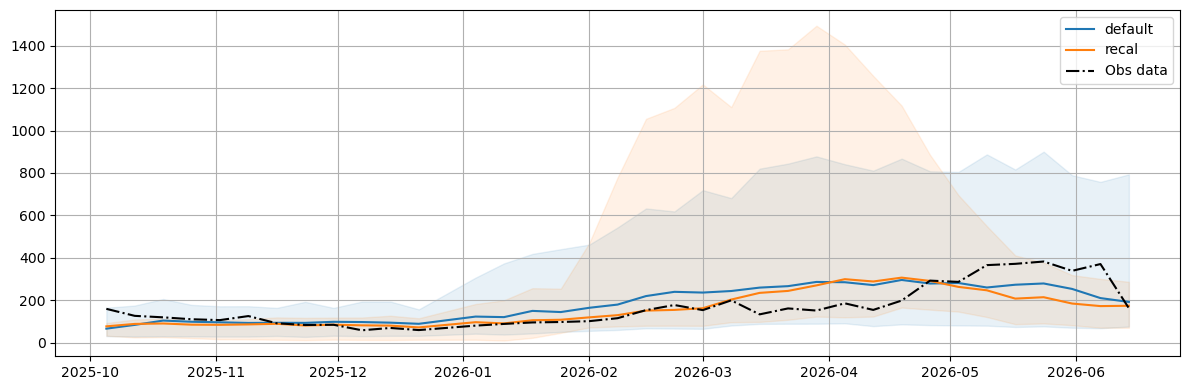

In [13]:
df_recal_end, df_default, df_ens = apply_recalibration(NonparametricRecalibrator(), df_preds, df_dengue_state, state, df_rank=df_rank_all)

plot_forecast(
    df_default,
    df_recal_end)


<Axes: >

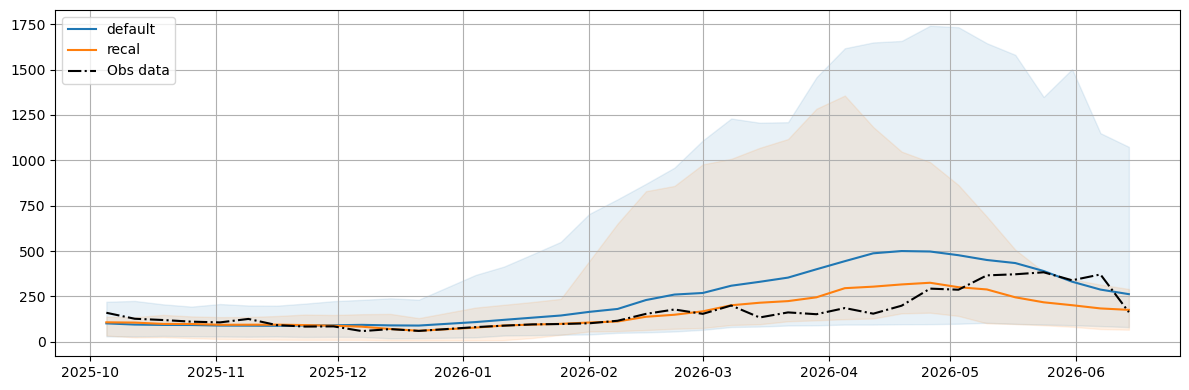

In [14]:
df_recal_end, df_default, df_ens = apply_recalibration(NonparametricRecalibrator(), df_preds, df_dengue_state, state)
plot_forecast(
    df_default,
    df_recal_end)


In [42]:
df_wis_models = pd.DataFrame()


for state in df_preds.adm_1.unique():

    try: 

        df_recal, df_default,df_ens = apply_recalibration(NonparametricRecalibrator(), df_preds, df_dengue_state, state, window = 10, rank =10, 
                                                   df_rank= df_rank_all)

        df_recal = df_recal.merge(df_default[['date', 'casos']], on = 'date')

        wis_def =  np.mean(compute_wis(
        df = df_default,
        observed_value= df_default['casos']))

        wis_rec =  np.mean(compute_wis(
            df = df_recal,
            observed_value= df_recal['casos']))

        df_wis_models = pd.concat([
            df_wis_models,
            pd.DataFrame([[state, wis_rec, wis_def]], columns = ['state', 'wis_rec', 'wis_def'])
        ],ignore_index = True)

    except: 
        print(state)



53
14


In [39]:
df_wis_no_parametric = df_wis_models

<Axes: xlabel='state', ylabel='log(WIS)'>

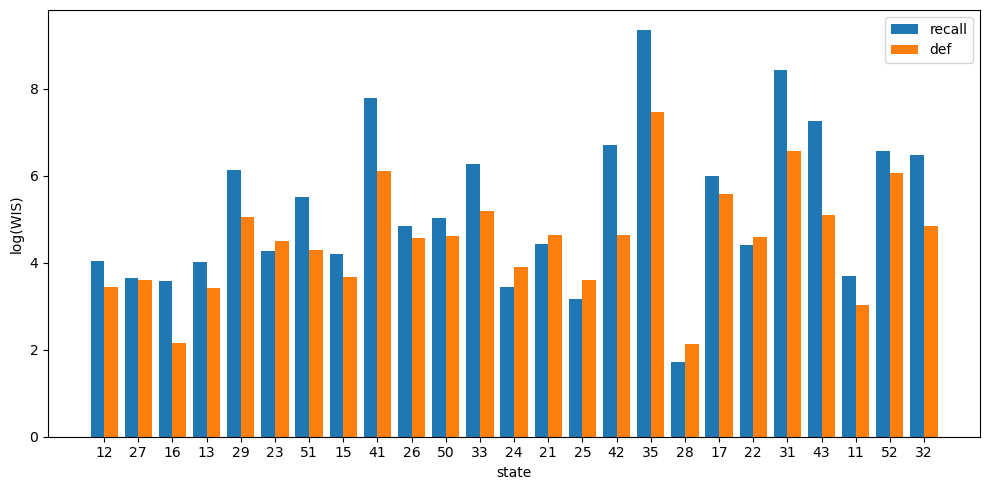

In [40]:
barplot_wis_comparison(
    df_wis_no_parametric,
    col1="wis_rec",
    col2="wis_def",
    label1="recall",
    label2="def",
    state_col="state",
    log=True
)

In [41]:
df_wis_no_parametric.loc[df_wis_no_parametric.wis_rec < df_wis_no_parametric.wis_def]

,state,wis_rec,wis_def
5,23,71.470588,89.221368
12,24,30.964214,49.901586
13,21,85.091426,103.957074
14,25,23.982385,36.371902
17,28,5.570153,8.428426
19,22,82.344036,98.618409


### Recalibração paramétrica:

In [43]:
df_wis_models = pd.DataFrame()


for state in df_preds.adm_1.unique():

    try: 

        df_recal, df_default,df_ens = apply_recalibration(ParametricRecalibrator(), df_preds, df_dengue_state, state, window = 10, df_rank = df_rank_all, rank = 5)

        df_recal = df_recal.merge(df_default[['date', 'casos']], on = 'date')

        wis_def =  np.mean(compute_wis(
        df = df_default,
        observed_value= df_default['casos']))

        wis_rec =  np.mean(compute_wis(
            df = df_recal,
            observed_value= df_recal['casos']))

        df_wis_models = pd.concat([
            df_wis_models,
            pd.DataFrame([[state, wis_rec, wis_def]], columns = ['state', 'wis_rec', 'wis_def'])
        ],ignore_index = True)

    except: 
        print(state)


<Axes: xlabel='state', ylabel='log(WIS)'>

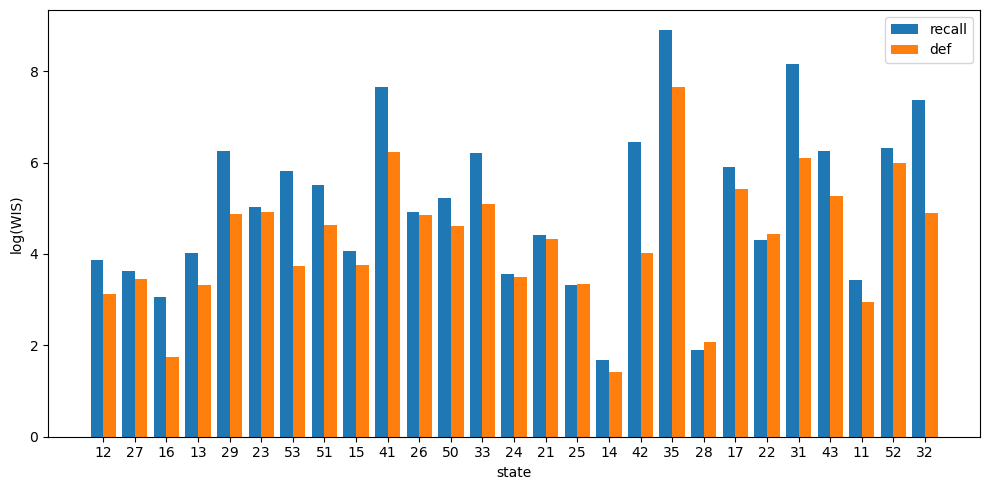

In [46]:
barplot_wis_comparison(
    df_wis_models,
    col1="wis_rec",
    col2="wis_def",
    label1="recall",
    label2="def",
    state_col="state",
    log=True
)

In [47]:
df_wis_models.loc[df_wis_models.wis_rec < df_wis_models.wis_def]

,state,wis_rec,wis_def
15,25,27.921352,28.521570
19,28,6.638604,7.896767
21,22,73.773765,83.687622


Raio -x estado:

In [48]:
def recalibrate_and_plot(
    recalibrator,
    df_preds,
    df_dengue_state,
    state,
    window=10,
    df_rank=None,
    rank=5,
    figsize=(10, 5)
):
    # Aplicar recalibração
    df_recal, df_default, df_ens = apply_recalibration(
        recalibrator,
        df_preds,
        df_dengue_state,
        state,
        window=window,
        df_rank=df_rank,
        rank=rank
    )

    # Plot
    _, ax = plt.subplots(figsize=figsize)

    # Casos observados
    ax.plot(
        df_ens.date,
        df_ens.casos,
        color="black",
        linestyle="-.",
        label="casos"
    )

    # Ensemble original
    ax.plot(
        df_ens.date,
        df_ens.pred,
        color="tab:blue",
        label="Ensemble"
    )

    ax.fill_between(
        df_ens.date,
        df_ens.lower_90,
        df_ens.upper_90,
        color="tab:blue",
        alpha=0.1
    )

    # Ensemble recalibrado
    ax.plot(
        df_recal.date,
        df_recal.pred,
        color="tab:red",
        label="Ens - recal"
    )

    ax.fill_between(
        df_recal.date,
        df_recal.lower_90,
        df_recal.upper_90,
        color="tab:red",
        alpha=0.1
    )

    ax.legend()
    ax.grid()
    ax.set_title(state)

    plt.tight_layout()

    return df_recal, df_default, df_ens, ax

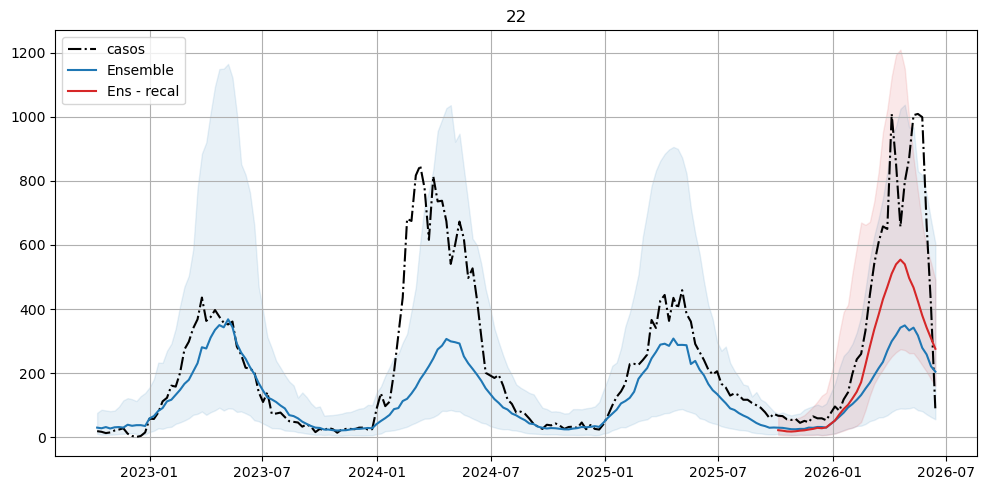

In [49]:
df_recal, df_default, df_ens, ax = recalibrate_and_plot(
    ParametricRecalibrator(),
    df_preds,
    df_dengue_state,
    state = 22,
    window=10,
    df_rank=None,
    rank=5,
    figsize=(10, 5))

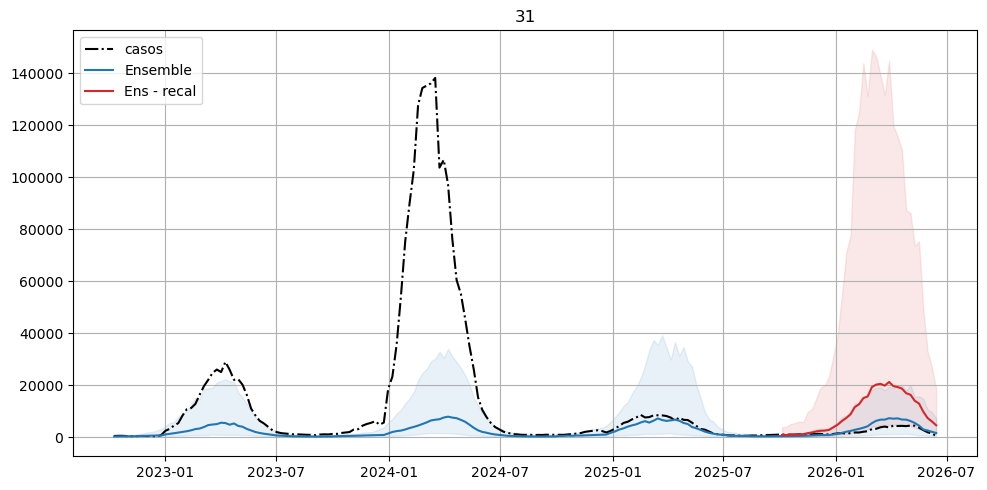

In [30]:
df_recal, df_default, df_ens, ax = recalibrate_and_plot(
    ParametricRecalibrator(),
    df_preds,
    df_dengue_state,
    state = 31,
    window=10,
    df_rank=None,
    rank=5,
    figsize=(10, 5))

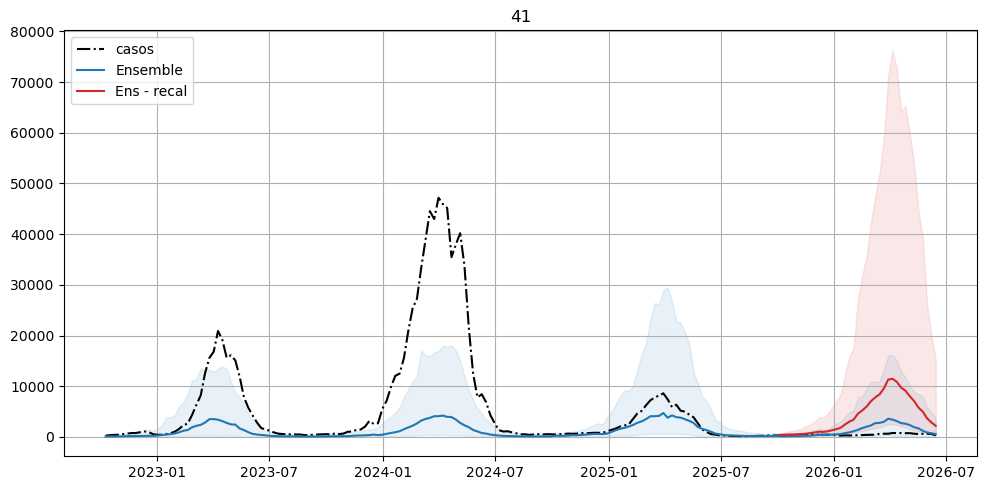

In [31]:
df_recal, df_default, df_ens, ax = recalibrate_and_plot(
    ParametricRecalibrator(),
    df_preds,
    df_dengue_state,
    state = 41,
    window=10,
    df_rank=None,
    rank=5,
    figsize=(10, 5))